In [1]:
import sys
print(sys.executable)

C:\Users\troll\.conda\envs\rdd-rd-detr\python.exe


In [2]:
!pip install kaggle


   ---------- ----------------------------- 1/4 [python-slugify]
   -------------------- ------------------- 2/4 [protobuf]
   -------------------- ------------------- 2/4 [protobuf]
   -------------------- ------------------- 2/4 [protobuf]
   -------------------- ------------------- 2/4 [protobuf]
   -------------------- ------------------- 2/4 [protobuf]
   -------------------- ------------------- 2/4 [protobuf]
   -------------------- ------------------- 2/4 [protobuf]
   -------------------- ------------------- 2/4 [protobuf]
   -------------------- ------------------- 2/4 [protobuf]
   -------------------- ------------------- 2/4 [protobuf]
   -------------------- ------------------- 2/4 [protobuf]
   -------------------- ------------------- 2/4 [protobuf]
   ------------------------------ --------- 3/4 [kaggle]
   ------------------------------ --------- 3/4 [kaggle]
   ------------------------------ --------- 3/4 [kaggle]
   ------------------------------ --------- 3/4 [kaggle

In [3]:
!kaggle --version

Kaggle API 1.7.4.5


In [5]:
import os
import shutil

source = r"C:\Users\troll\OneDrive\Desktop\kaggle.json"
target_dir = r"C:\Users\troll\.kaggle"
target = r"C:\Users\troll\.kaggle\kaggle.json"

os.makedirs(target_dir, exist_ok=True)
shutil.copy(source, target)

print("kaggle.json copied to:", target)

kaggle.json copied to: C:\Users\troll\.kaggle\kaggle.json


In [6]:
!kaggle datasets list -s "road damage detection"

ref                                                              title                                                       size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------  --------------------------------------------------  ------------  --------------------------  -------------  ---------  ---------------  
aliabdelmenam/rdd-2022                                           RDD 2022                                             10632799923  2025-02-23 02:30:31                  8327         48  0.6875           
rohitsuresh15/radroad-anomaly-detection                          RAD(Road Anomaly Detection)                           7849199282  2023-11-28 13:38:31.417000           2082         44  1.0              
lorenzoarcioni/road-damage-dataset-potholes-cracks-and-manholes  Road Damage Dataset: Potholes, Cracks and Manholes     194168092  2026-02-10 15:26:14                  2600         28  0.8

In [8]:
import os

os.makedirs("dataset", exist_ok=True)

In [9]:
!kaggle datasets download -d aliabdelmenam/rdd-2022 -p dataset

Dataset URL: https://www.kaggle.com/datasets/aliabdelmenam/rdd-2022
License(s): CC-BY-SA-4.0




  0%|          | 0.00/9.90G [00:00<?, ?B/s]
  1%|1         | 132M/9.90G [00:00<00:08, 1.21GB/s]
  2%|2         | 251M/9.90G [00:00<00:08, 1.23GB/s]
  4%|3         | 373M/9.90G [00:00<00:08, 1.25GB/s]
  5%|4         | 505M/9.90G [00:00<00:08, 1.25GB/s]
  6%|6         | 627M/9.90G [00:00<00:08, 1.24GB/s]
  7%|7         | 746M/9.90G [00:00<00:08, 1.22GB/s]
  9%|8         | 866M/9.90G [00:00<00:08, 1.19GB/s]
 10%|9         | 980M/9.90G [00:00<00:08, 1.19GB/s]
 11%|#         | 1.07G/9.90G [00:00<00:08, 1.14GB/s]
 12%|#1        | 1.18G/9.90G [00:01<00:08, 1.13GB/s]
 13%|#3        | 1.30G/9.90G [00:01<00:08, 1.11GB/s]
 14%|#4        | 1.42G/9.90G [00:01<00:08, 1.09GB/s]
 16%|#5        | 1.54G/9.90G [00:01<00:08, 1.09GB/s]
 17%|#6        | 1.65G/9.90G [00:01<00:07, 1.13GB/s]
 18%|#7        | 1.76G/9.90G [00:01<00:07, 1.11GB/s]
 19%|#8        | 1.87G/9.90G [00:01<00:07, 1.09GB/s]
 20%|#9        | 1.98G/9.90G [00:01<00:07, 1.07GB/s]
 21%|##        | 2.08G/9.90G [00:01<00:08, 1.02GB/s]
 22%|##1 

In [10]:
import os
os.listdir("dataset")

['rdd-2022.zip']

In [11]:
import zipfile
import os

zip_path = "dataset/rdd-2022.zip"
extract_path = "dataset/rdd2022"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted to:", extract_path)

Extracted to: dataset/rdd2022


In [12]:
os.listdir("dataset/rdd2022")

['RDD_SPLIT']

In [13]:
import os

base_path = "dataset/rdd2022/RDD_SPLIT"

os.listdir(base_path)

['test', 'train', 'val']

In [14]:
import os

base_path = "dataset/rdd2022/RDD_SPLIT"

print("Train:", os.listdir(os.path.join(base_path, "train")))
print("Val:", os.listdir(os.path.join(base_path, "val")))
print("Test:", os.listdir(os.path.join(base_path, "test")))

Train: ['images', 'labels']
Val: ['images', 'labels']
Test: ['images', 'labels']


## Count images an

In [15]:
import os

base_path = "dataset/rdd2022/RDD_SPLIT"

for split in ["train", "val", "test"]:
    images_dir = os.path.join(base_path, split, "images")
    labels_dir = os.path.join(base_path, split, "labels")

    num_images = len(os.listdir(images_dir))
    num_labels = len(os.listdir(labels_dir))

    print(f"{split}:")
    print(f"  images: {num_images}")
    print(f"  labels: {num_labels}")

train:
  images: 26869
  labels: 26869
val:
  images: 5758
  labels: 5758
test:
  images: 5758
  labels: 5758


## original train class counts

In [19]:
from pathlib import Path
from collections import Counter

label_dir = Path("dataset/rdd2022/RDD_SPLIT/train/labels")

class_counts = Counter()
empty_files = 0
total_label_files = 0

for label_file in label_dir.glob("*.txt"):
    total_label_files += 1
    
    text = label_file.read_text().strip()
    
    if text == "":
        empty_files += 1
        continue
    
    for line in text.splitlines():
        parts = line.strip().split()
        if len(parts) > 0:
            class_id = int(parts[0])
            class_counts[class_id] += 1

print("=== Original Train Set Class Counts ===")
print("Total train label files:", total_label_files)
print("Empty train label files (background images):", empty_files)
print(dict(sorted(class_counts.items())))

=== Original Train Set Class Counts ===
Total train label files: 26869
Empty train label files (background images): 8097
{0: 18201, 1: 8386, 2: 7527, 3: 7554, 4: 4628}


## Check val and test

In [20]:
from pathlib import Path
from collections import Counter

base_path = Path("dataset/rdd2022/RDD_SPLIT")

for split in ["train", "val", "test"]:
    label_dir = base_path / split / "labels"
    
    class_counts = Counter()
    empty_files = 0
    total_label_files = 0
    
    for label_file in label_dir.glob("*.txt"):
        total_label_files += 1
        
        text = label_file.read_text().strip()
        
        if text == "":
            empty_files += 1
            continue
        
        for line in text.splitlines():
            parts = line.strip().split()
            if len(parts) > 0:
                class_id = int(parts[0])
                class_counts[class_id] += 1
    
    print(f"\n=== {split.upper()} Set Class Counts ===")
    print("Total label files:", total_label_files)
    print("Empty label files/background images:", empty_files)
    print("Class counts:", dict(sorted(class_counts.items())))


=== TRAIN Set Class Counts ===
Total label files: 26869
Empty label files/background images: 8097
Class counts: {0: 18201, 1: 8386, 2: 7527, 3: 7554, 4: 4628}

=== VAL Set Class Counts ===
Total label files: 5758
Empty label files/background images: 1837
Class counts: {0: 3890, 1: 1769, 2: 1553, 3: 1564, 4: 965}

=== TEST Set Class Counts ===
Total label files: 5758
Empty label files/background images: 1790
Class counts: {0: 3925, 1: 1675, 2: 1537, 3: 1587, 4: 951}


## data.yaml

In [22]:
import yaml
import os

base_path = os.path.abspath("dataset/rdd2022/RDD_SPLIT")

data_yaml = {
    "path": base_path,
    "train": "train/images",
    "val": "val/images",
    "test": "test/images",
    "names": {
        0: "D00",
        1: "D10",
        2: "D20",
        3: "D40",
        4: "Other"
    }
}

with open("data.yaml", "w") as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print("data.yaml updated successfully:\n")

with open("data.yaml", "r") as f:
    print(f.read())

data.yaml updated successfully:

path: C:\Users\troll\dataset\rdd2022\RDD_SPLIT
train: train/images
val: val/images
test: test/images
names:
  0: D00
  1: D10
  2: D20
  3: D40
  4: Other



In [23]:
from pathlib import Path
from collections import Counter

base_path = Path("dataset/rdd2022/RDD_SPLIT")

class_names = {
    0: "D00",
    1: "D10",
    2: "D20",
    3: "D40",
    4: "Other"
}

for split in ["train", "val", "test"]:
    label_dir = base_path / split / "labels"
    
    class_counts = Counter()
    empty_files = 0
    total_label_files = 0
    
    for label_file in label_dir.glob("*.txt"):
        total_label_files += 1
        text = label_file.read_text().strip()
        
        if text == "":
            empty_files += 1
            continue
        
        for line in text.splitlines():
            parts = line.strip().split()
            if len(parts) > 0:
                class_id = int(parts[0])
                class_counts[class_id] += 1
    
    print(f"\n=== {split.upper()} Set Class Counts with Mapping ===")
    print("Total label files:", total_label_files)
    print("Empty label files / background images:", empty_files)
    
    for class_id in sorted(class_names.keys()):
        count = class_counts.get(class_id, 0)
        print(f"Class {class_id} ({class_names[class_id]}): {count}")


=== TRAIN Set Class Counts with Mapping ===
Total label files: 26869
Empty label files / background images: 8097
Class 0 (D00): 18201
Class 1 (D10): 8386
Class 2 (D20): 7527
Class 3 (D40): 7554
Class 4 (Other): 4628

=== VAL Set Class Counts with Mapping ===
Total label files: 5758
Empty label files / background images: 1837
Class 0 (D00): 3890
Class 1 (D10): 1769
Class 2 (D20): 1553
Class 3 (D40): 1564
Class 4 (Other): 965

=== TEST Set Class Counts with Mapping ===
Total label files: 5758
Empty label files / background images: 1790
Class 0 (D00): 3925
Class 1 (D10): 1675
Class 2 (D20): 1537
Class 3 (D40): 1587
Class 4 (Other): 951


## Visualize original training class distribution

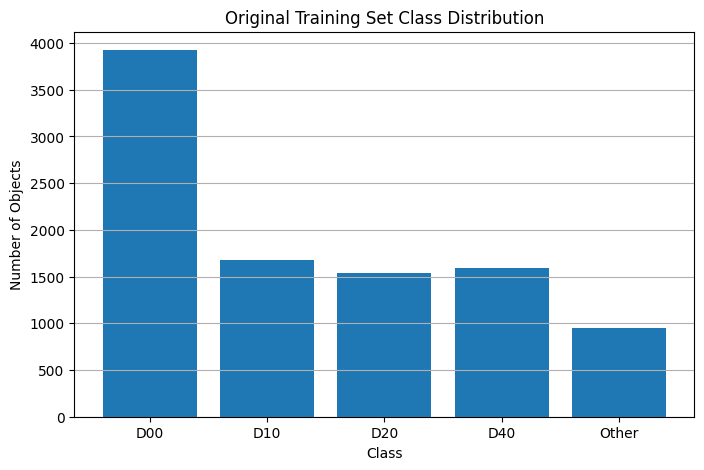

In [24]:
import matplotlib.pyplot as plt

# Class ID mapping
class_names = {
    0: "D00",
    1: "D10",
    2: "D20",
    3: "D40",
    4: "Other"
}

# Use the class_counts from the previous step
labels = [class_names[i] for i in sorted(class_names.keys())]
counts = [class_counts.get(i, 0) for i in sorted(class_names.keys())]

plt.figure(figsize=(8, 5))
plt.bar(labels, counts)
plt.title("Original Training Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Objects")
plt.grid(axis="y")
plt.show()

## training RT_DETR.L


In [26]:
from ultralytics import RTDETR

model = RTDETR("rtdetr-l.pt")

results = model.train(
    data="data.yaml",
    epochs=50,
    imgsz=640,
    batch=8,
    device=0,
    workers=8,
    patience=10,
    project="runs/rdd_rtdetr",
    name="rtdetr_l_50epochs_earlystop",
    exist_ok=True
)

Ultralytics 8.4.46  Python-3.10.20 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4080 Laptop GPU, 12282MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=rtdetr_l_50epochs_earlystop, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_m

C:\Users\troll\.conda\envs\rdd-rd-detr\lib\site-packages\torch\autograd\graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:164.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/50      6.84G     0.9167      1.756     0.4617         17        640: 100% ━━━━━━━━━━━━ 3359/3359 2.4it/s 23:21<0.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 360/360 7.4it/s 48.4s<0.1s
                   all       5758       9740      0.497       0.45      0.422      0.196

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


C:\Users\troll\.conda\envs\rdd-rd-detr\lib\site-packages\torch\autograd\graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:164.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/50      7.09G     0.7193     0.7523      0.294          2        640: 100% ━━━━━━━━━━━━ 3359/3359 2.9it/s 19:08<0.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 360/360 7.4it/s 48.4s<0.1s
                   all       5758       9740      0.523      0.455      0.435      0.206

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       3/50      7.12G     0.6269     0.7965     0.2476         22        640: 0% ──────────── 0/3359  0.5s

...

      48/50      7.11G     0.4879     0.5116     0.2003         10        640: 100% ━━━━━━━━━━━━ 3359/3359 3.1it/s 18:15<0.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 360/360 7.5it/s 48.2s<0.1s
                   all       5758       9740      0.695      0.602      0.642      0.331

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      49/50      6.94G     0.4531     0.4636     0.2082         16        640: 0% ──────────── 0/3359  0.5s

C:\Users\troll\.conda\envs\rdd-rd-detr\lib\site-packages\torch\autograd\graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:164.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      49/50      6.96G     0.4762     0.5007     0.1938         12        640: 100% ━━━━━━━━━━━━ 3359/3359 3.1it/s 18:07<0.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 360/360 7.5it/s 48.1s<0.1s
                   all       5758       9740      0.695      0.601      0.642      0.331

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


C:\Users\troll\.conda\envs\rdd-rd-detr\lib\site-packages\torch\autograd\graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:164.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      50/50       7.1G     0.4638     0.4925       0.19          6        640: 100% ━━━━━━━━━━━━ 3359/3359 3.1it/s 18:14<0.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 360/360 7.5it/s 48.0s<0.1s
                   all       5758       9740      0.696      0.599       0.64      0.331

50 epochs completed in 17.169 hours.
Optimizer stripped from C:\Users\troll\runs\detect\runs\rdd_rtdetr\rtdetr_l_50epochs_earlystop\weights\last.pt, 66.2MB
Optimizer stripped from C:\Users\troll\runs\detect\runs\rdd_rtdetr\rtdetr_l_50epochs_earlystop\weights\best.pt, 66.2MB

Validating C:\Users\troll\runs\detect\runs\rdd_rtdetr\rtdetr_l_50epochs_earlystop\weights\best.pt...
Ultralytics 8.4.46  Python-3.10.20 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4080 Laptop GPU, 12282MiB)
rt-detr-l summary: 310 layers, 31,994,015 parameters, 0 gradients, 103.5 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50

## the training results

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

run_dir = Path(r"C:\Users\troll\runs\detect\runs\rdd_rtdetr\rtdetr_l_50epochs_earlystop")
results_csv = run_dir / "results.csv"

df = pd.read_csv(results_csv)
df.columns = [c.strip() for c in df.columns]

print(df.columns.tolist())
print(df.head())

['epoch', 'time', 'train/giou_loss', 'train/cls_loss', 'train/l1_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/giou_loss', 'val/cls_loss', 'val/l1_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2', 'lr/pg3', 'lr/pg4', 'lr/pg5', 'lr/pg6', 'lr/pg7']
   epoch      time  train/giou_loss  train/cls_loss  train/l1_loss  \
0      1   1450.79          0.91668         1.75586        0.46172   
1      2   2649.95          0.71930         0.75233        0.29402   
2      3   3790.83          0.80672         0.70667        0.30997   
3      4   8567.10          0.84029         0.69415        0.31868   
4      5  10448.60          0.81696         0.68727        0.30899   

   metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
0               0.49705            0.45003           0.42183   
1               0.52330            0.45515           0.43518   
2               0.50712            0.42239           0.42088   
3               0.52538            

## Plot training loss curves

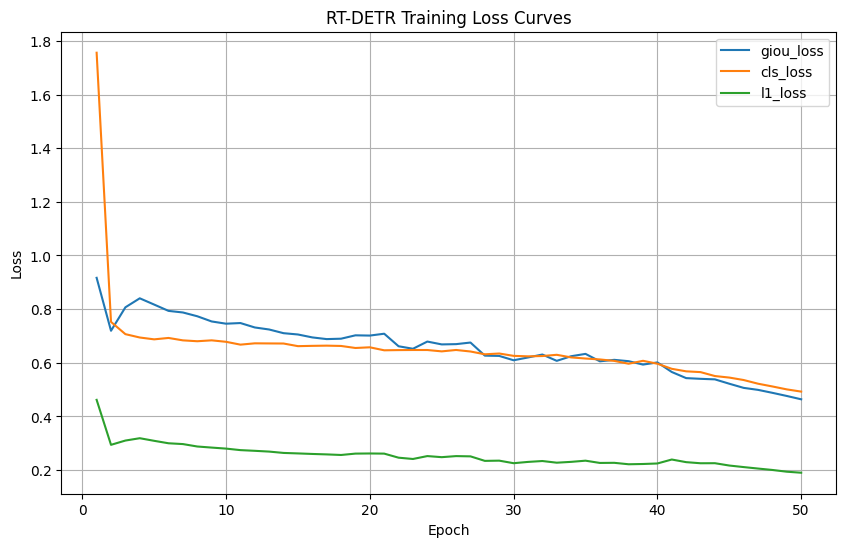

In [28]:
plt.figure(figsize=(10, 6))
plt.plot(df["epoch"], df["train/giou_loss"], label="giou_loss")
plt.plot(df["epoch"], df["train/cls_loss"], label="cls_loss")
plt.plot(df["epoch"], df["train/l1_loss"], label="l1_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RT-DETR Training Loss Curves")
plt.legend()
plt.grid(True)
plt.show()

## Plot validation metric curves

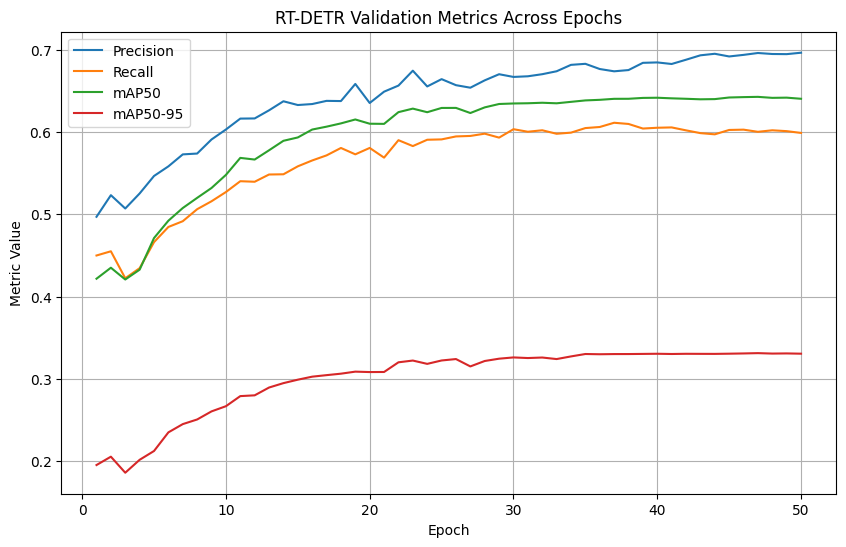

In [30]:
plt.figure(figsize=(10, 6))
plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
plt.xlabel("Epoch")
plt.ylabel("Metric Value")
plt.title("RT-DETR Validation Metrics Across Epochs")
plt.legend()
plt.grid(True)
plt.show()

## Per-class final performance histogram

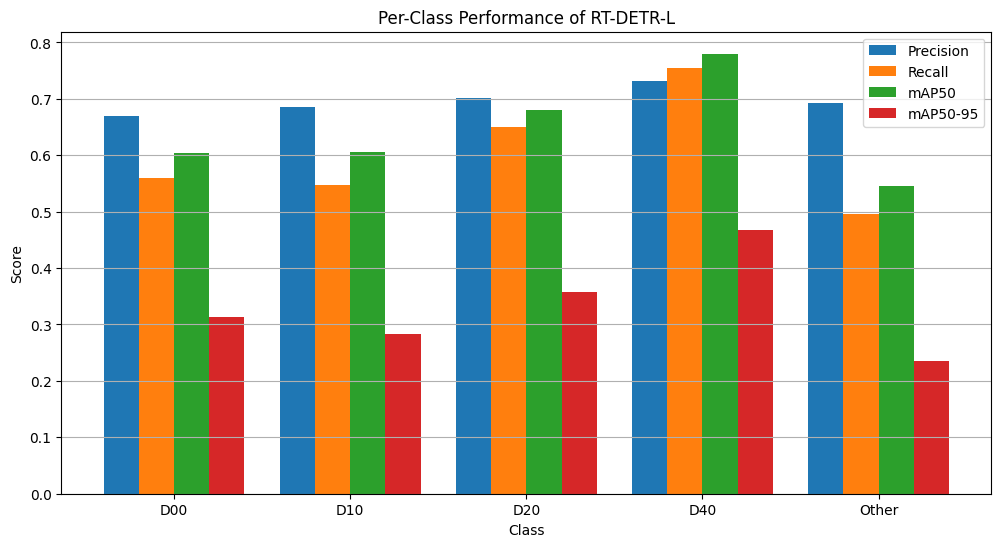

In [32]:
classes = ["D00", "D10", "D20", "D40", "Other"]
precision = [0.67, 0.686, 0.701, 0.731, 0.693]
recall = [0.56, 0.548, 0.65, 0.755, 0.495]
map50 = [0.604, 0.606, 0.68, 0.78, 0.545]
map5095 = [0.313, 0.283, 0.357, 0.467, 0.236]

x = range(len(classes))
width = 0.2

plt.figure(figsize=(12, 6))
plt.bar([i - 1.5*width for i in x], precision, width=width, label="Precision")
plt.bar([i - 0.5*width for i in x], recall, width=width, label="Recall")
plt.bar([i + 0.5*width for i in x], map50, width=width, label="mAP50")
plt.bar([i + 1.5*width for i in x], map5095, width=width, label="mAP50-95")

plt.xticks(list(x), classes)
plt.xlabel("Class")
plt.ylabel("Score")
plt.title("Per-Class Performance of RT-DETR-L")
plt.legend()
plt.grid(True, axis="y")
plt.show()

## Confusion matrix

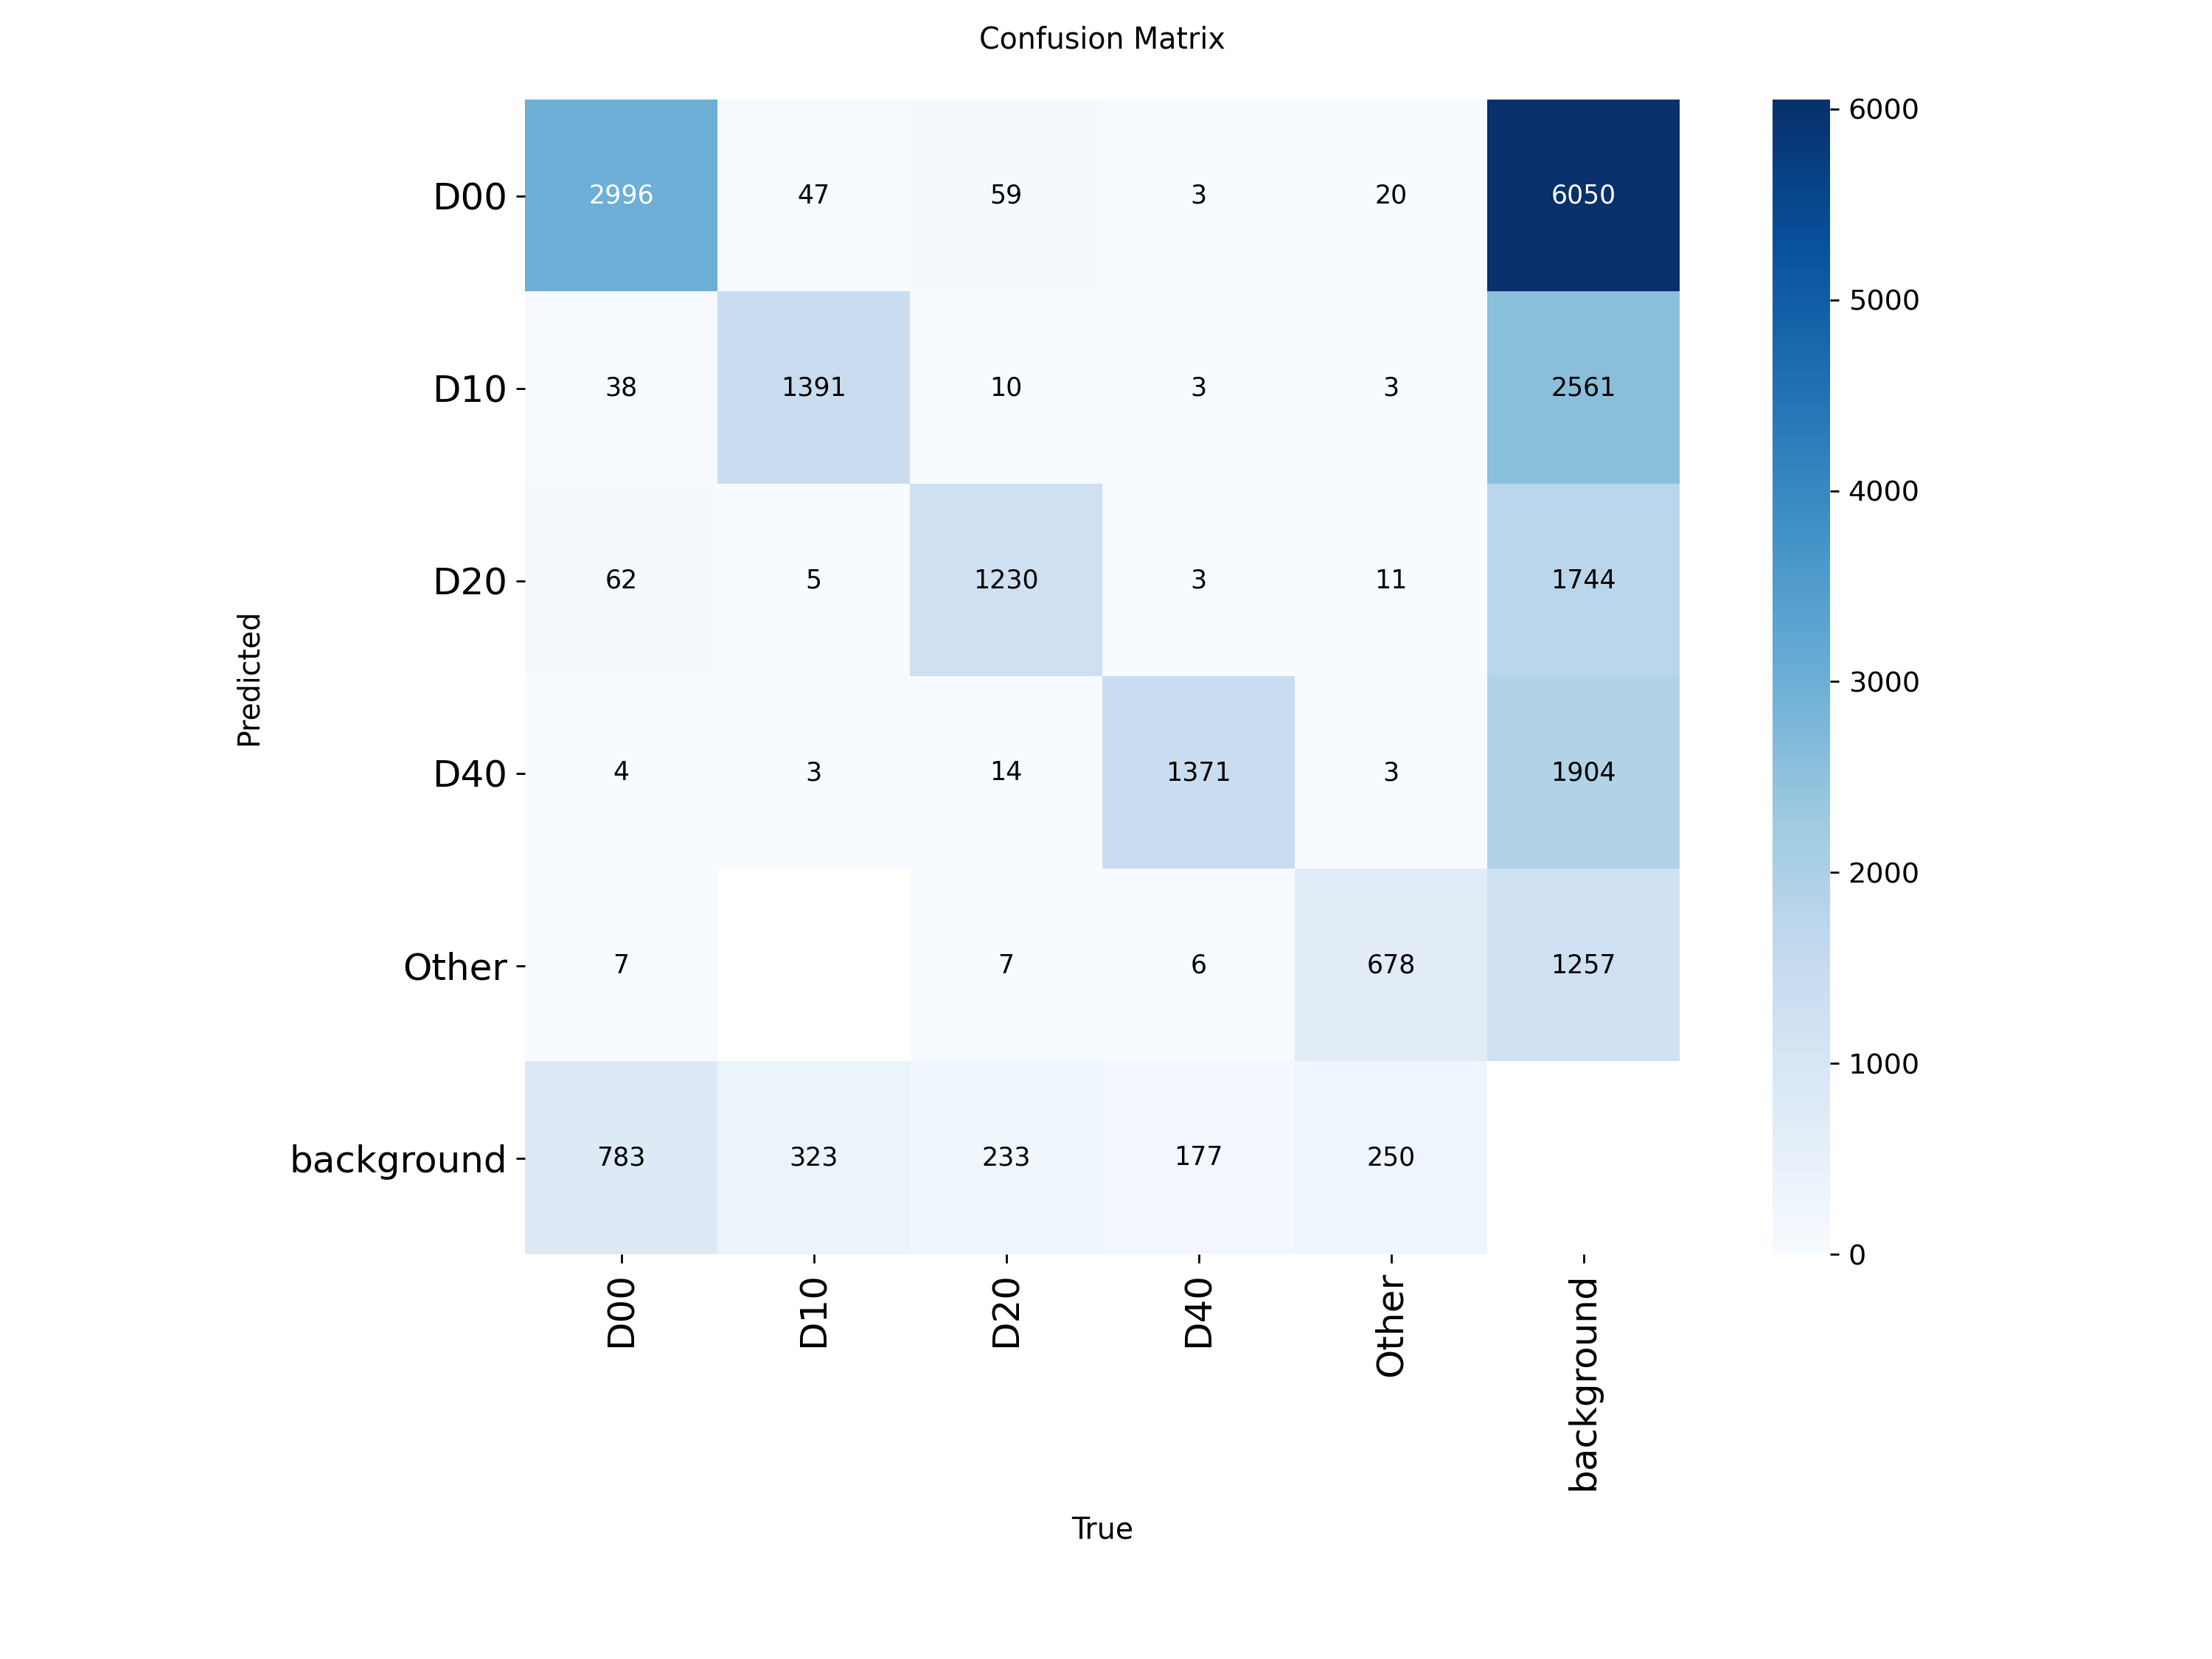

In [33]:
from IPython.display import Image, display

display(Image(filename=str(run_dir / "confusion_matrix.png")))

# ## YOLOv8 Baseline Training

In [35]:
from ultralytics import YOLO

model = YOLO("yolov8l.pt")
print("YOLOv8l loaded successfully")

YOLOv8l loaded successfully


In [38]:
from ultralytics import YOLO

model = YOLO("yolov8l.pt")

model.train(
    data="data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    workers=4,
    project=r"C:\Users\troll\runs\detect\runs\yolo_rdd",
    name="yolov8l_50epochs_batch16",
    save=True
)

New https://pypi.org/project/ultralytics/8.4.47 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.46  Python-3.10.20 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4080 Laptop GPU, 12282MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000186A44119C0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
    

## the per-class performance chart

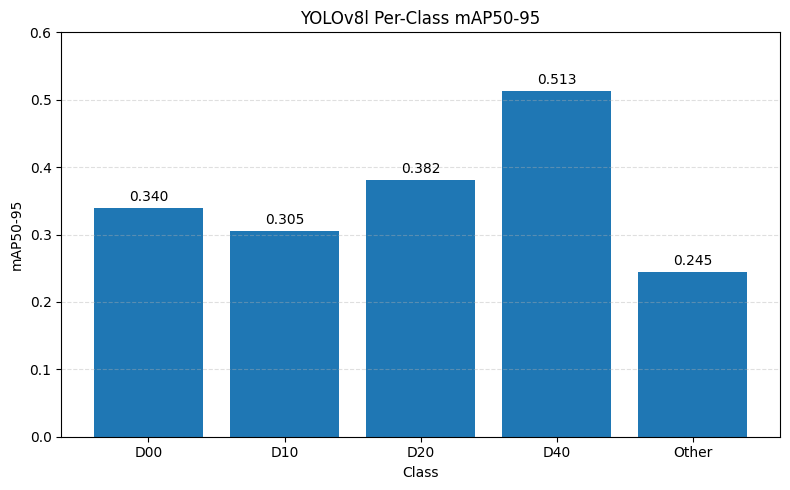

In [39]:
import matplotlib.pyplot as plt

classes = ["D00", "D10", "D20", "D40", "Other"]
yolo_map5095 = [0.33953, 0.30544, 0.38161, 0.51267, 0.24487]

plt.figure(figsize=(8, 5))
plt.bar(classes, yolo_map5095)

plt.title("YOLOv8l Per-Class mAP50-95")
plt.xlabel("Class")
plt.ylabel("mAP50-95")
plt.ylim(0, 0.6)

for i, v in enumerate(yolo_map5095):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## comparison table between RT-DETR-L and YOLOv8l

In [40]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["RT-DETR-L", "YOLOv8l"],
    "Precision": [0.696, 0.670],
    "Recall": [0.602, 0.603],
    "mAP50": [0.643, 0.643],
    "mAP50-95": [0.331, 0.357],
    "Inference Time (ms/image)": [5.4, 6.1],
    "Parameters": [31994015, 43610463],
    "Training Time (hours)": [17.169, 16.777]
})

comparison_df

,Model,Precision,Recall,mAP50,mAP50-95,Inference Time (ms/image),Parameters,Training Time (hours)
0,RT-DETR-L,0.696,0.602,0.643,0.331,5.4,31994015,17.169
1,YOLOv8l,0.670,0.603,0.643,0.357,6.1,43610463,16.777


## the per-class comparison bar chart

In [43]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["RT-DETR-L", "YOLOv8l"],
    "Precision": [0.696, 0.670],
    "Recall": [0.602, 0.603],
    "mAP50": [0.643, 0.643],
    "mAP50-95": [0.331, 0.357],
    "Inference Time (ms/image)": [5.4, 6.1],
    "Parameters": [31994015, 43610463],
    "Training Time (hours)": [17.169, 16.777]
})

comparison_df

,Model,Precision,Recall,mAP50,mAP50-95,Inference Time (ms/image),Parameters,Training Time (hours)
0,RT-DETR-L,0.696,0.602,0.643,0.331,5.4,31994015,17.169
1,YOLOv8l,0.670,0.603,0.643,0.357,6.1,43610463,16.777


## Per-class comparison bar chart

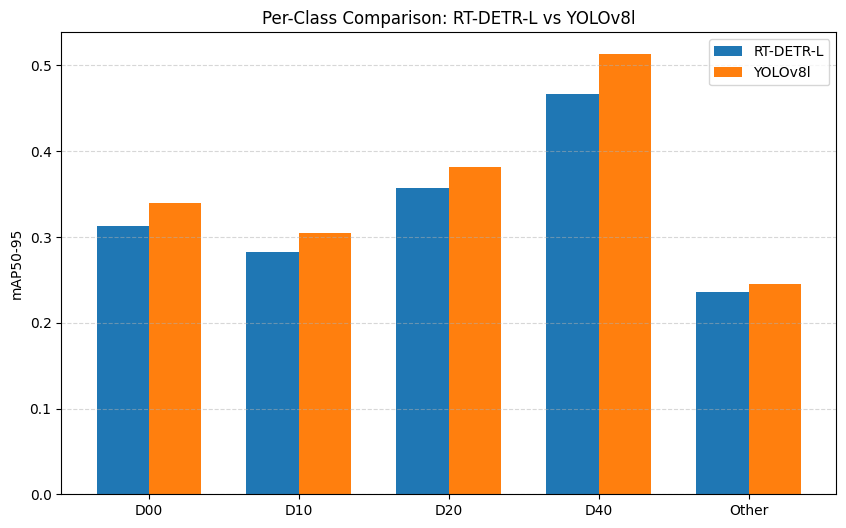

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

per_class_df = pd.DataFrame({
    "Class": ["D00", "D10", "D20", "D40", "Other"],
    "RT-DETR mAP50-95": [0.313, 0.283, 0.357, 0.467, 0.236],
    "YOLOv8l mAP50-95": [0.340, 0.305, 0.382, 0.513, 0.245]
})

x = np.arange(len(per_class_df["Class"]))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, per_class_df["RT-DETR mAP50-95"], width, label="RT-DETR-L")
plt.bar(x + width/2, per_class_df["YOLOv8l mAP50-95"], width, label="YOLOv8l")

plt.xticks(x, per_class_df["Class"])
plt.ylabel("mAP50-95")
plt.title("Per-Class Comparison: RT-DETR-L vs YOLOv8l")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

## Overall Metric Comparison 

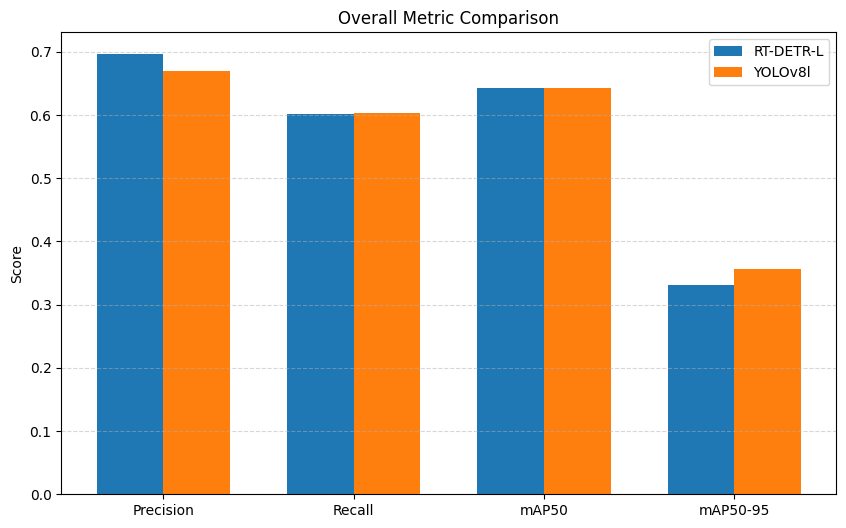

In [46]:
metrics = ["Precision", "Recall", "mAP50", "mAP50-95"]
rtdetr_vals = [0.696, 0.602, 0.643, 0.331]
yolo_vals   = [0.670, 0.603, 0.643, 0.357]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, rtdetr_vals, width, label="RT-DETR-L")
plt.bar(x + width/2, yolo_vals, width, label="YOLOv8l")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Overall Metric Comparison")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

## RT-DETR vs YOLO results section

In [47]:
results_text = """
Results Comparison: RT-DETR-L vs YOLOv8l

Both RT-DETR-L and YOLOv8l achieved very similar overall mAP50 performance on the RDD2022 dataset, with both models reaching 0.643. 
In terms of precision, RT-DETR-L performed slightly better (0.696) than YOLOv8l (0.670), while recall was almost identical, with YOLOv8l showing a very small advantage (0.603 vs 0.602).

For the stricter mAP50-95 metric, YOLOv8l outperformed RT-DETR-L, achieving 0.357 compared to 0.331. 
This indicates that YOLOv8l produced better localization quality across multiple IoU thresholds.

From the per-class results, YOLOv8l performed better on every damage category, especially on class D40, where it achieved 0.513 mAP50-95 compared to 0.467 for RT-DETR-L. 
YOLOv8l also showed improvements in D00, D10, D20, and Other, suggesting more robust detection quality across all classes.

In terms of speed, RT-DETR-L was slightly faster during inference, requiring 5.4 ms per image, while YOLOv8l needed 6.1 ms per image. 
RT-DETR-L also used fewer parameters (31.99M) than YOLOv8l (43.61M). 
Training time for both models was very similar, with RT-DETR-L taking 17.169 hours and YOLOv8l taking 16.777 hours.

Overall, RT-DETR-L offered slightly better precision, faster inference, and a smaller model size. 
However, YOLOv8l achieved the better mAP50-95 and stronger per-class performance, making it the better model in this experiment for overall detection quality.
"""
print(results_text)


Results Comparison: RT-DETR-L vs YOLOv8l

Both RT-DETR-L and YOLOv8l achieved very similar overall mAP50 performance on the RDD2022 dataset, with both models reaching 0.643. 
In terms of precision, RT-DETR-L performed slightly better (0.696) than YOLOv8l (0.670), while recall was almost identical, with YOLOv8l showing a very small advantage (0.603 vs 0.602).

For the stricter mAP50-95 metric, YOLOv8l outperformed RT-DETR-L, achieving 0.357 compared to 0.331. 
This indicates that YOLOv8l produced better localization quality across multiple IoU thresholds.

From the per-class results, YOLOv8l performed better on every damage category, especially on class D40, where it achieved 0.513 mAP50-95 compared to 0.467 for RT-DETR-L. 
YOLOv8l also showed improvements in D00, D10, D20, and Other, suggesting more robust detection quality across all classes.

In terms of speed, RT-DETR-L was slightly faster during inference, requiring 5.4 ms per image, while YOLOv8l needed 6.1 ms per image. 
RT-DETR